# L-NODEC: Plasma Thermal Dose Delivery

This notebook demonstrates L-NODEC for atmospheric pressure plasma jet (APPJ) thermal dose delivery.

**Problem (Thermal Dose Control):**
- State: $x = [T, \text{CEM}]$ (Temperature in °C, Cumulative Equivalent Minutes)
- Dynamics: Nonlinear thermal model with heat transfer
- Control: $u \in [1, 5]$ W (power input)
- Target: $z = (45, 1.5)$ (reach target temperature and thermal dose)
- Constraint: $T \leq 45°C$ (safety limit)

**Experimental Design:**
- **Training:** Initial state $x_0 = (37, 0)$ °C (body temperature, no prior dose)
- **Evaluation:** Test robustness with perturbed initial conditions

**Methods Compared:**
1. **L-NODEC**: Lyapunov loss with exponential stability
2. **L-NODEC-Constrained**: With temperature constraint $T \leq 45°C$
3. **NODEC-Terminal**: Terminal cost baseline

**Note:** Configuration aligned with OLDER/appj.py (Temp weight 1e-6, CEM weight 1.0; T ≤ 45°C).

## Setup

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from policy import NeuralPolicy
from lyapunov import QuadraticLyapunov
from loss import LyapunovLoss
from simulator import Simulator
from trainer import LNODECTrainer
from systems import plasma_dynamics
from cost import TerminalCost
from nodec_trainer import NODECTrainer
from constraints import ConstraintHandler
from samplers import NormalSetToPointSampler
from visualization import set_plot_style, COLORS

# Apply publication-quality plotting style
set_plot_style()

# Auto-reload visualization module when it changes
%load_ext autoreload
%autoreload 2
%matplotlib inline

print("Modules loaded. Auto-reload enabled.")

Modules loaded. Auto-reload enabled.


## Configuration

In [2]:
# Device and dtype
device = torch.device("cpu")
dtype = torch.float64

# Set random seed for reproducibility
torch.manual_seed(100)
np.random.seed(100)

# System parameters
state_dim = 2  # [Temperature (°C), CEM (min)]
control_dim = 1  # [Power (W)]
u_min = 1.0  # Minimum power (W)
u_max = 5.0  # Maximum power (W)

# Temperature conversion
k2cel = 273.15
T_up = 318.15  # 45°C

# Initial condition and target
x0 = torch.tensor([310.15 - k2cel, 0.0], dtype=dtype, device=device)  # [37°C, 0 min]
z_target = torch.tensor([T_up - k2cel, 1.5], dtype=dtype, device=device)  # [45°C, 1.5 min]

# Normalization factor (for temperature only)
normalization_factor = 40.0

def normalize_state(x):
    """Normalize temperature component for better neural network training"""
    y = x.clone()
    if len(y.shape) != 1:
        y[..., 0] = y[..., 0] / normalization_factor
    else:
        y[0] = y[0] / normalization_factor
    return y

# Time discretization
t_final = 100.0
num_steps = 500
time_grid = torch.linspace(0, t_final, num_steps, dtype=dtype, device=device)

# Training hyperparameters 
num_epochs = 150  # increase epochs for batch training
batch_size = 4  # train on B>1 sampled ICs
learning_rate = 0.025
kappa = 0.001  # match OLDER?

# Lyapunov/Cost matrix P - FIXED TO MATCH OLDER EXACTLY
# OLDER Lya potential used: (CEM error)^2 + 1e-6*(Temp error)^2
# With our diagonal mapping [Temp, CEM], choose:
#   P_diag = [1e-6 for Temperature, 1.0 for CEM]
P_diag = [1e-6, 1.0]  
P = torch.diag(torch.tensor(P_diag, dtype=dtype, device=device))

# Temperature constraint
T_max = T_up - k2cel  # 45°C (same as target temperature)
print("Configuration")
print(f"  State dim: {state_dim}, Control dim: {control_dim}")
print(f"  Control bounds: [{u_min}, {u_max}] W")
print(f"  Time horizon: [0, {t_final}] with {num_steps} steps")
print(f"\nInitial state: {x0.numpy()} [°C, min]")
print(f"Target state: {z_target.numpy()} [°C, min]")
print(f"Temperature constraint: T ≤ {T_max}°C")
print(f"\nCost/Lyapunov matrix P:\n{P}")
print(f"  P diagonal: {P_diag} (Temperature weight, CEM weight)")
print(f"  Matches OLDER: Temp weight=1e-10, CEM weight=0.01")
print(f"  κ (kappa): {kappa} (stability enforcement)")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {num_epochs}")

Configuration
  State dim: 2, Control dim: 1
  Control bounds: [1.0, 5.0] W
  Time horizon: [0, 100.0] with 500 steps

Initial state: [37.  0.] [°C, min]
Target state: [45.   1.5] [°C, min]
Temperature constraint: T ≤ 45.0°C

Cost/Lyapunov matrix P:
tensor([[1.0000e-06, 0.0000e+00],
        [0.0000e+00, 1.0000e+00]], dtype=torch.float64)
  P diagonal: [1e-06, 1.0] (Temperature weight, CEM weight)
  Matches OLDER: Temp weight=1e-10, CEM weight=0.01
  κ (kappa): 0.001 (stability enforcement)
  Learning rate: 0.025
  Epochs: 150


## Create Components

In [3]:
# Set seed before creating policy
torch.manual_seed(100)

# 1. Neural Policy (for L-NODEC) - WITH NORMALIZATION AND SIMPLER ARCHITECTURE
policy = NeuralPolicy(
    state_dim=state_dim,
    control_dim=control_dim,
    hidden_dims=[32,32],  # Single hidden layer to match OLDER implementation
    u_min=u_min,
    u_max=u_max,
    normalize_fn=normalize_state,  # ADD NORMALIZATION!
).to(device=device, dtype=dtype)

print(f"Policy: {sum(p.numel() for p in policy.parameters())} parameters")

# 2. Lyapunov function
lyapunov_fn = QuadraticLyapunov(P)

# 3. Lyapunov loss
lyapunov_loss = LyapunovLoss(lyapunov_fn, kappa=kappa)

# 4. Simulator (shared by all methods)
simulator = Simulator(
    dynamics_fn=plasma_dynamics,
    method="rk4",
    rtol=1e-6,
    atol=1e-8,
)

# 5. Optimizer - Consider using Adam like OLDER implementation
#optimizer = torch.optim.Adam(policy.parameters(), lr=learning_rate)
optimizer = torch.optim.RMSprop(policy.parameters(), lr=learning_rate)

# 6. Sampler: Normal ICs (Temp ~ N(mean=37°C, std=1.0), CEM=0)
dataset_sampler = NormalSetToPointSampler(
    x0_mean=x0,
    x0_std=torch.tensor([0.5, 0.0], dtype=dtype, device=device),
    x_target=z_target,
    device=device,
    dtype=dtype,
)

trainer = LNODECTrainer(
    policy=policy,
    dynamics_fn=plasma_dynamics,
    lyapunov_loss=lyapunov_loss,
    simulator=simulator,
    optimizer=optimizer,
    dataset_sampler=dataset_sampler,
)

print("\nComponents created successfully!")

Policy: 1185 parameters

Components created successfully!


## Train L-NODEC Policy

In [4]:
import os

# Helper function to format kappa for filenames
def format_kappa_for_filename(kappa_value):
    """Format kappa value for use in filename, handling both integers and decimals."""
    if isinstance(kappa_value, (int, np.integer)):
        return str(kappa_value)
    elif isinstance(kappa_value, (float, np.floating)):
        # For floats, replace decimal point with 'p' (e.g., 0.1 -> 0p1)
        kappa_str = f"{kappa_value:.10g}"  # Use general format to avoid trailing zeros
        return kappa_str.replace('.', 'p')
    else:
        # Handle torch tensors
        kappa_val = float(kappa_value)
        kappa_str = f"{kappa_val:.10g}"
        return kappa_str.replace('.', 'p')

load_from_saved = False  # Set to True to load saved policy
kappa_str = format_kappa_for_filename(kappa)
SAVE_PATH = f"results_plasma_lnodec_unconstrained_kappa{kappa_str}.pt"

if load_from_saved and os.path.exists(SAVE_PATH):
    print(f"Loading trained policy from {SAVE_PATH}...")
    checkpoint = torch.load(SAVE_PATH)
    policy.load_state_dict(checkpoint['policy_state_dict'])
    history = checkpoint['history']
    print(f"Loaded! Training was done for {len(history['loss'])} epochs.")
    print(f"Final loss: {history['loss'][-1]:.4e}")
else:
    print(f"Training L-NODEC policy from scratch (κ={kappa})...")
    print(f"Will save to: {SAVE_PATH}\n")
    history = trainer.train(
        num_epochs=num_epochs,
        time_grid=time_grid,
        batch_size=batch_size,
        log_interval=20,
        verbose=True,
    )
    
    # Save trained policy with kappa value in checkpoint
    torch.save({
        'policy_state_dict': policy.state_dict(),
        'history': history,
        'kappa': kappa,  # Store actual kappa value
        'config': {
            'state_dim': state_dim,
            'control_dim': control_dim,
            'hidden_dims': [32, 32],
            'u_min': u_min,
            'u_max': u_max,
            'P_diag': P_diag
        }
    }, SAVE_PATH)
    print(f"\nTraining complete! Saved to {SAVE_PATH}")

Training L-NODEC policy from scratch (κ=0.001)...
Will save to: results_plasma_lnodec_unconstrained_kappa0p001.pt

Epoch    0/150: Loss=1.3661e-02, Final Dist=3.2974, V_decay=0.2948
Epoch   20/150: Loss=9.3453e-01, Final Dist=9.3052, V_decay=0.9841
Epoch   40/150: Loss=9.2523e-01, Final Dist=9.3048, V_decay=0.9833
Epoch   60/150: Loss=6.8766e-03, Final Dist=9.1826, V_decay=0.0249
Epoch   80/150: Loss=5.5831e-03, Final Dist=9.1817, V_decay=0.0185
Epoch  100/150: Loss=8.9627e-03, Final Dist=9.1817, V_decay=0.0185
Epoch  120/150: Loss=8.0154e-03, Final Dist=9.1817, V_decay=0.0185
Epoch  140/150: Loss=7.4061e-03, Final Dist=9.1817, V_decay=0.0185
Epoch  149/150: Loss=8.9507e-03, Final Dist=9.1817, V_decay=0.0185

[Best Model] Restored policy from epoch 103 (loss=3.3403e-03)


Training complete! Saved to results_plasma_lnodec_unconstrained_kappa0p001.pt


## Train NODEC Baseline

In [5]:
kappa_str = format_kappa_for_filename(kappa)
SAVE_PATH_TERMINAL = f"results_plasma_nodec_terminal_kappa{kappa_str}.pt"

print(f"NODEC-Terminal: Terminal cost (x(T)-z)ᵀP(x(T)-z)")
print(f"Kappa={kappa} (affects filename but NODEC doesn't use Lyapunov)")

torch.manual_seed(100)

policy_terminal = NeuralPolicy(
    state_dim=state_dim,
    control_dim=control_dim,
    hidden_dims=[32, 32],
    u_min=u_min,
    u_max=u_max,
    normalize_fn=normalize_state,
).to(device=device, dtype=dtype)

terminal_cost = TerminalCost(P_phi=P)

optimizer_terminal = torch.optim.RMSprop(
    policy_terminal.parameters(),
    lr=0.025,
)

trainer_terminal = NODECTrainer(
    policy=policy_terminal,
    dynamics_fn=plasma_dynamics,
    cost_fn=terminal_cost,
    simulator=simulator,
    optimizer=optimizer_terminal,
    dataset_sampler=dataset_sampler,
)

if load_from_saved and os.path.exists(SAVE_PATH_TERMINAL):
    print(f"Loading from: {SAVE_PATH_TERMINAL}")
    checkpoint = torch.load(SAVE_PATH_TERMINAL)
    policy_terminal.load_state_dict(checkpoint['policy_state_dict'])
    history_terminal = checkpoint['history']
    print(f"Loaded! Final loss: {history_terminal['loss'][-1]:.4e}")
else:
    print(f"Training NODEC-Terminal with RMSprop...")
    print(f"Will save to: {SAVE_PATH_TERMINAL}\n")
    history_terminal = trainer_terminal.train(
        num_epochs=num_epochs,
        time_grid=time_grid,
        batch_size=batch_size,
        log_interval=20,
        verbose=True,
    )
    torch.save({
        'policy_state_dict': policy_terminal.state_dict(), 
        'history': history_terminal,
        'kappa': kappa,  # Store for reference (though NODEC doesn't use it)
        'config': {
            'state_dim': state_dim,
            'control_dim': control_dim,
            'hidden_dims': [32, 32],
            'u_min': u_min,
            'u_max': u_max,
            'P_diag': P_diag
        }
    }, SAVE_PATH_TERMINAL)

print(f"Final distance: {history_terminal['final_distance'][-1]:.4f}")
print("✓ NODEC-Terminal trained!")

NODEC-Terminal: Terminal cost (x(T)-z)ᵀP(x(T)-z)
Kappa=0.001 (affects filename but NODEC doesn't use Lyapunov)
Training NODEC-Terminal with RMSprop...
Will save to: results_plasma_nodec_terminal_kappa0p001.pt

Epoch    0/150: Loss=6.6324e-01, Final Dist=3.2974
Epoch   20/150: Loss=8.4259e-05, Final Dist=9.1786
Epoch   40/150: Loss=8.4251e-05, Final Dist=9.1787
Epoch   60/150: Loss=8.4250e-05, Final Dist=9.1787
Epoch   80/150: Loss=8.4251e-05, Final Dist=9.1787
Epoch  100/150: Loss=8.4255e-05, Final Dist=9.1787
Epoch  120/150: Loss=8.4254e-05, Final Dist=9.1787
Epoch  140/150: Loss=8.4250e-05, Final Dist=9.1787
Epoch  149/150: Loss=8.4258e-05, Final Dist=9.1787
Final distance: 9.1787
✓ NODEC-Terminal trained!


## Train L-NODEC with Temperature Constraint

In [6]:
kappa_str = format_kappa_for_filename(kappa)
SAVE_PATH_CONSTRAINED = f"results_plasma_lnodec_constrained_kappa{kappa_str}.pt"

# Temperature constraint - set ABOVE target to make problem feasible
# Target is 45°C; enforce hard safety limit at 45°C
T_max_constrained = (T_up - k2cel)  # 45°C, match OLDER constraint

def temperature_constraint(x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
    """g(x,u) = T - T_max ≤ 0"""
    T = x[..., 0] if x.ndim > 1 else x[0]
    return T - T_max_constrained

# Create constraint handler with smooth penalty
# Uses: P(g) = β · [τ · softplus(g/τ)]²
constraint_handler = ConstraintHandler(
    constraint_fns=[temperature_constraint],
    beta=50.0,    # Penalty weight
    tau=0.1,      # Temperature for smooth max (smaller = sharper)
)

print("="*60)
print(f"L-NODEC-Constrained: T ≤ {T_max_constrained}°C (κ={kappa})")
print("="*60)
print(f"Target temperature: {z_target[0].item()}°C")
print(f"Constraint: {T_max_constrained}°C (allows {T_max_constrained - z_target[0].item()}°C margin)")
print(f"Constraint method: Smooth penalty P(g) = β·[τ·softplus(g/τ)]²")
print(f"  β (beta): {constraint_handler.beta} (penalty strength)")
print(f"  τ (tau):  {constraint_handler.tau} (smoothness, smaller=sharper)")
print(f"  κ (kappa): {kappa} (exponential stability rate)")

torch.manual_seed(100)

policy_constrained = NeuralPolicy(
    state_dim=state_dim,
    control_dim=control_dim,
    hidden_dims=[32, 32],
    u_min=u_min,
    u_max=u_max,
    normalize_fn=normalize_state,
).to(device=device, dtype=dtype)

lyapunov_loss_constrained = LyapunovLoss(
    lyapunov_fn=lyapunov_fn,
    kappa=kappa,
    constraint_handler=constraint_handler,
)

optimizer_constrained = torch.optim.Adam(
    policy_constrained.parameters(),
    lr=learning_rate,
)

trainer_constrained = LNODECTrainer(
    policy=policy_constrained,
    dynamics_fn=plasma_dynamics,
    lyapunov_loss=lyapunov_loss_constrained,
    simulator=simulator,
    optimizer=optimizer_constrained,
    dataset_sampler=dataset_sampler,
)

if load_from_saved and os.path.exists(SAVE_PATH_CONSTRAINED):
    print(f"Loading from: {SAVE_PATH_CONSTRAINED}")
    checkpoint = torch.load(SAVE_PATH_CONSTRAINED)
    policy_constrained.load_state_dict(checkpoint['policy_state_dict'])
    history_constrained = checkpoint['history']
    print(f"Loaded! Final loss: {history_constrained['loss'][-1]:.4e}")
else:
    print(f"\nTraining with smooth penalty...")
    print(f"Will save to: {SAVE_PATH_CONSTRAINED}\n")
    history_constrained = trainer_constrained.train(
        num_epochs=num_epochs,
        time_grid=time_grid,
        batch_size=batch_size,
        log_interval=20,
        verbose=True,
    )
    
    torch.save({
        'policy_state_dict': policy_constrained.state_dict(),
        'history': history_constrained,
        'kappa': kappa,  # Store actual kappa value
        'config': {
            'state_dim': state_dim,
            'control_dim': control_dim,
            'hidden_dims': [32, 32],
            'u_min': u_min,
            'u_max': u_max,
            'P_diag': P_diag,
            'beta': constraint_handler.beta,
            'tau': constraint_handler.tau
        }
    }, SAVE_PATH_CONSTRAINED)

print(f"\nFinal distance: {history_constrained['final_distance'][-1]:.4f}")
print("✓ L-NODEC-Constrained trained with smooth penalty!")

L-NODEC-Constrained: T ≤ 45.0°C (κ=0.001)
Target temperature: 45.0°C
Constraint: 45.0°C (allows 0.0°C margin)
Constraint method: Smooth penalty P(g) = β·[τ·softplus(g/τ)]²
  β (beta): 50.0 (penalty strength)
  τ (tau):  0.1 (smoothness, smaller=sharper)
  κ (kappa): 0.001 (exponential stability rate)

Training with smooth penalty...
Will save to: results_plasma_lnodec_constrained_kappa0p001.pt

Epoch    0/150: Loss=1.3661e-02, Final Dist=3.2974, V_decay=0.2948
Epoch   20/150: Loss=8.9223e-01, Final Dist=9.0015, V_decay=0.9805
Epoch   40/150: Loss=8.9839e-01, Final Dist=9.1105, V_decay=0.9810
Epoch   60/150: Loss=9.0164e-01, Final Dist=9.1205, V_decay=0.9813
Epoch   80/150: Loss=8.9898e-01, Final Dist=9.1210, V_decay=0.9811
Epoch  100/150: Loss=9.0705e-01, Final Dist=9.1192, V_decay=0.9817
Epoch  120/150: Loss=9.0441e-01, Final Dist=9.1178, V_decay=0.9815
Epoch  140/150: Loss=9.0349e-01, Final Dist=9.1160, V_decay=0.9815
Epoch  149/150: Loss=9.0556e-01, Final Dist=9.1150, V_decay=0.9816

## Evaluate All Methods

In [7]:
print("Evaluating all methods...")

result_lnodec = trainer.evaluate(x0, z_target, time_grid, compute_stability_metrics=False)
result_constrained = trainer_constrained.evaluate(x0, z_target, time_grid, compute_stability_metrics=False)
result_terminal = trainer_terminal.evaluate(x0, z_target, time_grid)

# Extract trajectories
traj_lnodec = result_lnodec['trajectory'].cpu().numpy()
traj_constrained = result_constrained['trajectory'].cpu().numpy()
traj_terminal = result_terminal['trajectory'].cpu().numpy()

# Extract controls
ctrl_lnodec = result_lnodec['controls'].cpu().numpy()
ctrl_constrained = result_constrained['controls'].cpu().numpy()
ctrl_terminal = result_terminal['controls'].cpu().numpy()

time_grid_np = time_grid.cpu().numpy()

print("\nFinal distances:")
print(f"  L-NODEC:             {result_lnodec['final_distance'].item():.4f}")
print(f"  L-NODEC-Constrained: {result_constrained['final_distance'].item():.4f}")
print(f"  NODEC-Terminal:      {result_terminal['final_distance'].item():.4f}")

print(f"\nTemperature constraint (T ≤ {T_max_constrained}°C) violations:")
print(f"  L-NODEC:             max T = {traj_lnodec[:, 0].max():.3f}°C {'❌' if traj_lnodec[:, 0].max() > T_max_constrained else '✅'}")
print(f"  L-NODEC-Constrained: max T = {traj_constrained[:, 0].max():.3f}°C {'❌' if traj_constrained[:, 0].max() > T_max_constrained else '✅'}")
print(f"  NODEC-Terminal:      max T = {traj_terminal[:, 0].max():.3f}°C {'❌' if traj_terminal[:, 0].max() > T_max_constrained else '✅'}")

Evaluating all methods...

Final distances:
  L-NODEC:             9.1817
  L-NODEC-Constrained: 6.4101
  NODEC-Terminal:      9.1787

Temperature constraint (T ≤ 45.0°C) violations:
  L-NODEC:             max T = 46.527°C ❌
  L-NODEC-Constrained: max T = 39.871°C ✅
  NODEC-Terminal:      max T = 46.665°C ❌


## Comparison Plot: All Methods

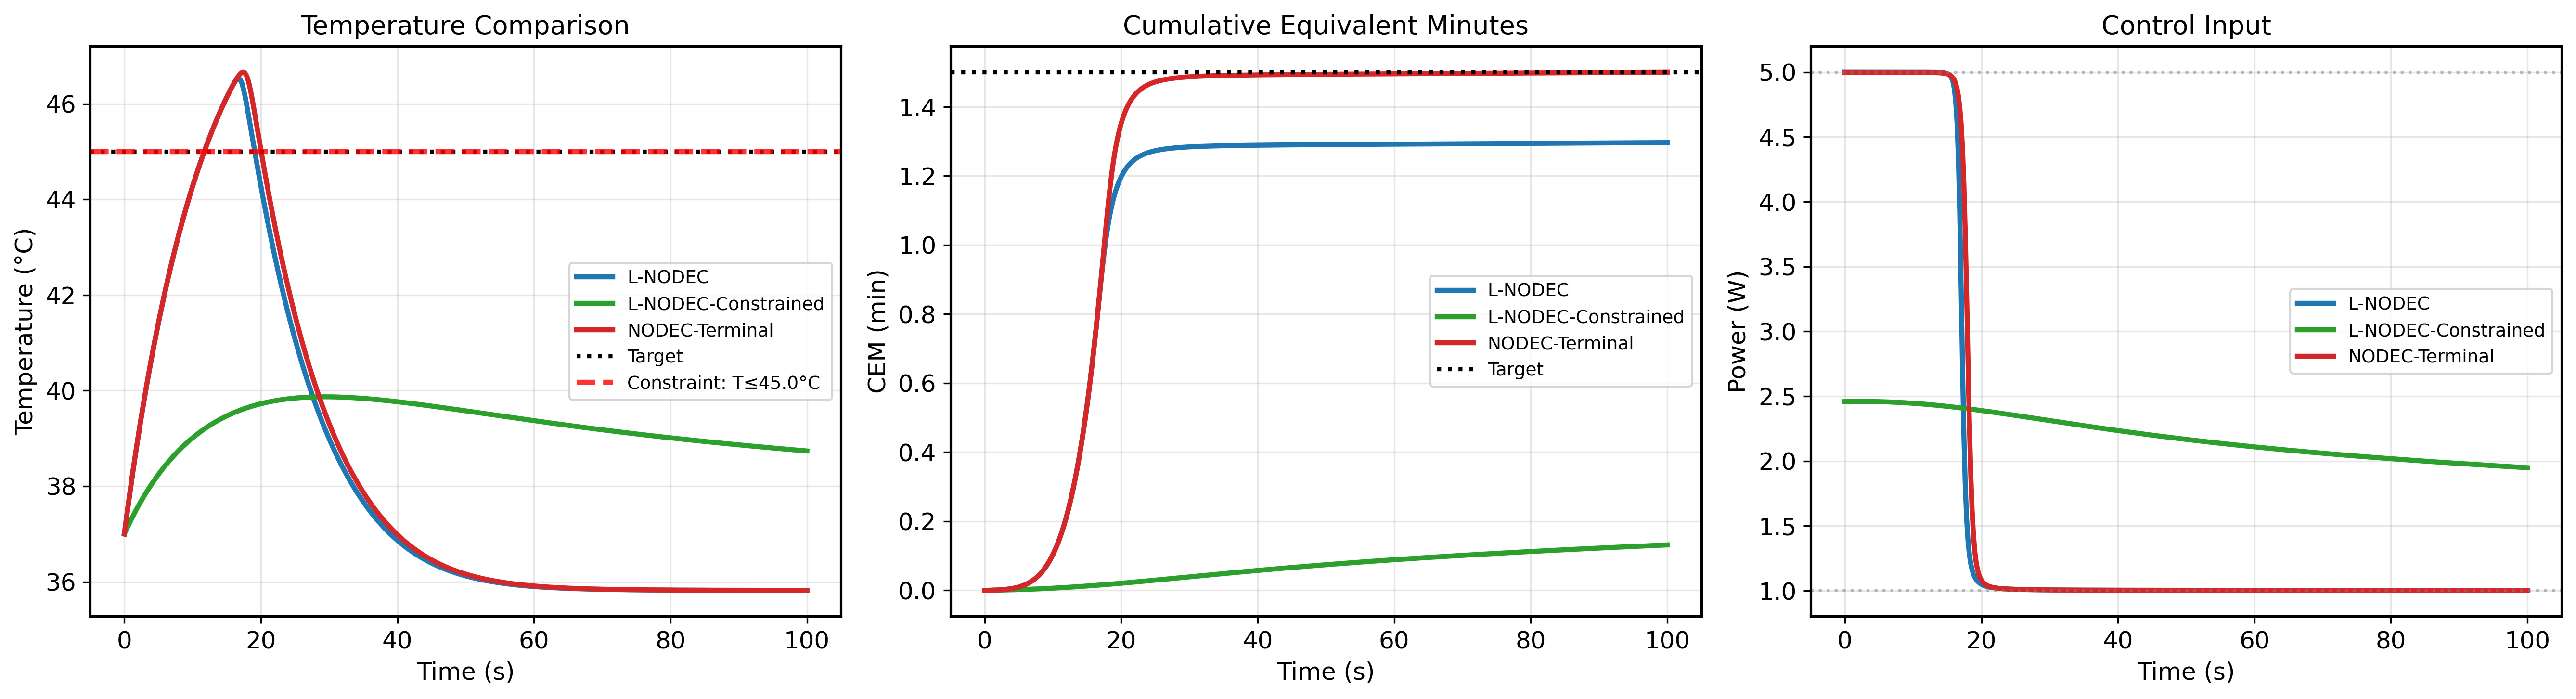

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_methods = {
    'L-NODEC': COLORS['primary'],
    'L-NODEC-Constrained': COLORS['success'],
    'NODEC-Terminal': COLORS['danger'],
}

trajectories_all = {
    'L-NODEC': traj_lnodec,
    'L-NODEC-Constrained': traj_constrained,
    'NODEC-Terminal': traj_terminal,
}

controls_all = {
    'L-NODEC': ctrl_lnodec,
    'L-NODEC-Constrained': ctrl_constrained,
    'NODEC-Terminal': ctrl_terminal,
}

# Plot 1: Temperature
for method_name, traj in trajectories_all.items():
    axes[0].plot(time_grid_np, traj[:, 0], color=colors_methods[method_name],
                 linewidth=2.5, label=method_name)
axes[0].axhline(z_target[0].item(), color='black', linestyle=':', linewidth=2, label='Target')
axes[0].axhline(T_max_constrained, color='red', linestyle='--', linewidth=2.5, label=f'Constraint: T≤{T_max_constrained}°C', alpha=0.8)
axes[0].set_xlabel('Time (s)', fontsize=12)
axes[0].set_ylabel('Temperature (°C)', fontsize=12)
axes[0].set_title('Temperature Comparison', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: CEM (thermal dose)
for method_name, traj in trajectories_all.items():
    axes[1].plot(time_grid_np, traj[:, 1], color=colors_methods[method_name],
                 linewidth=2.5, label=method_name)
axes[1].axhline(z_target[1].item(), color='black', linestyle=':', linewidth=2, label='Target')
axes[1].set_xlabel('Time (s)', fontsize=12)
axes[1].set_ylabel('CEM (min)', fontsize=12)
axes[1].set_title('Cumulative Equivalent Minutes', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Plot 3: Control (power)
for method_name, ctrl in controls_all.items():
    axes[2].plot(time_grid_np, ctrl, color=colors_methods[method_name],
                 linewidth=2.5, label=method_name)
axes[2].axhline(u_min, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
axes[2].axhline(u_max, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
axes[2].set_xlabel('Time (s)', fontsize=12)
axes[2].set_ylabel('Power (W)', fontsize=12)
axes[2].set_title('Control Input', fontsize=13)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Phase Portrait: Temperature vs CEM

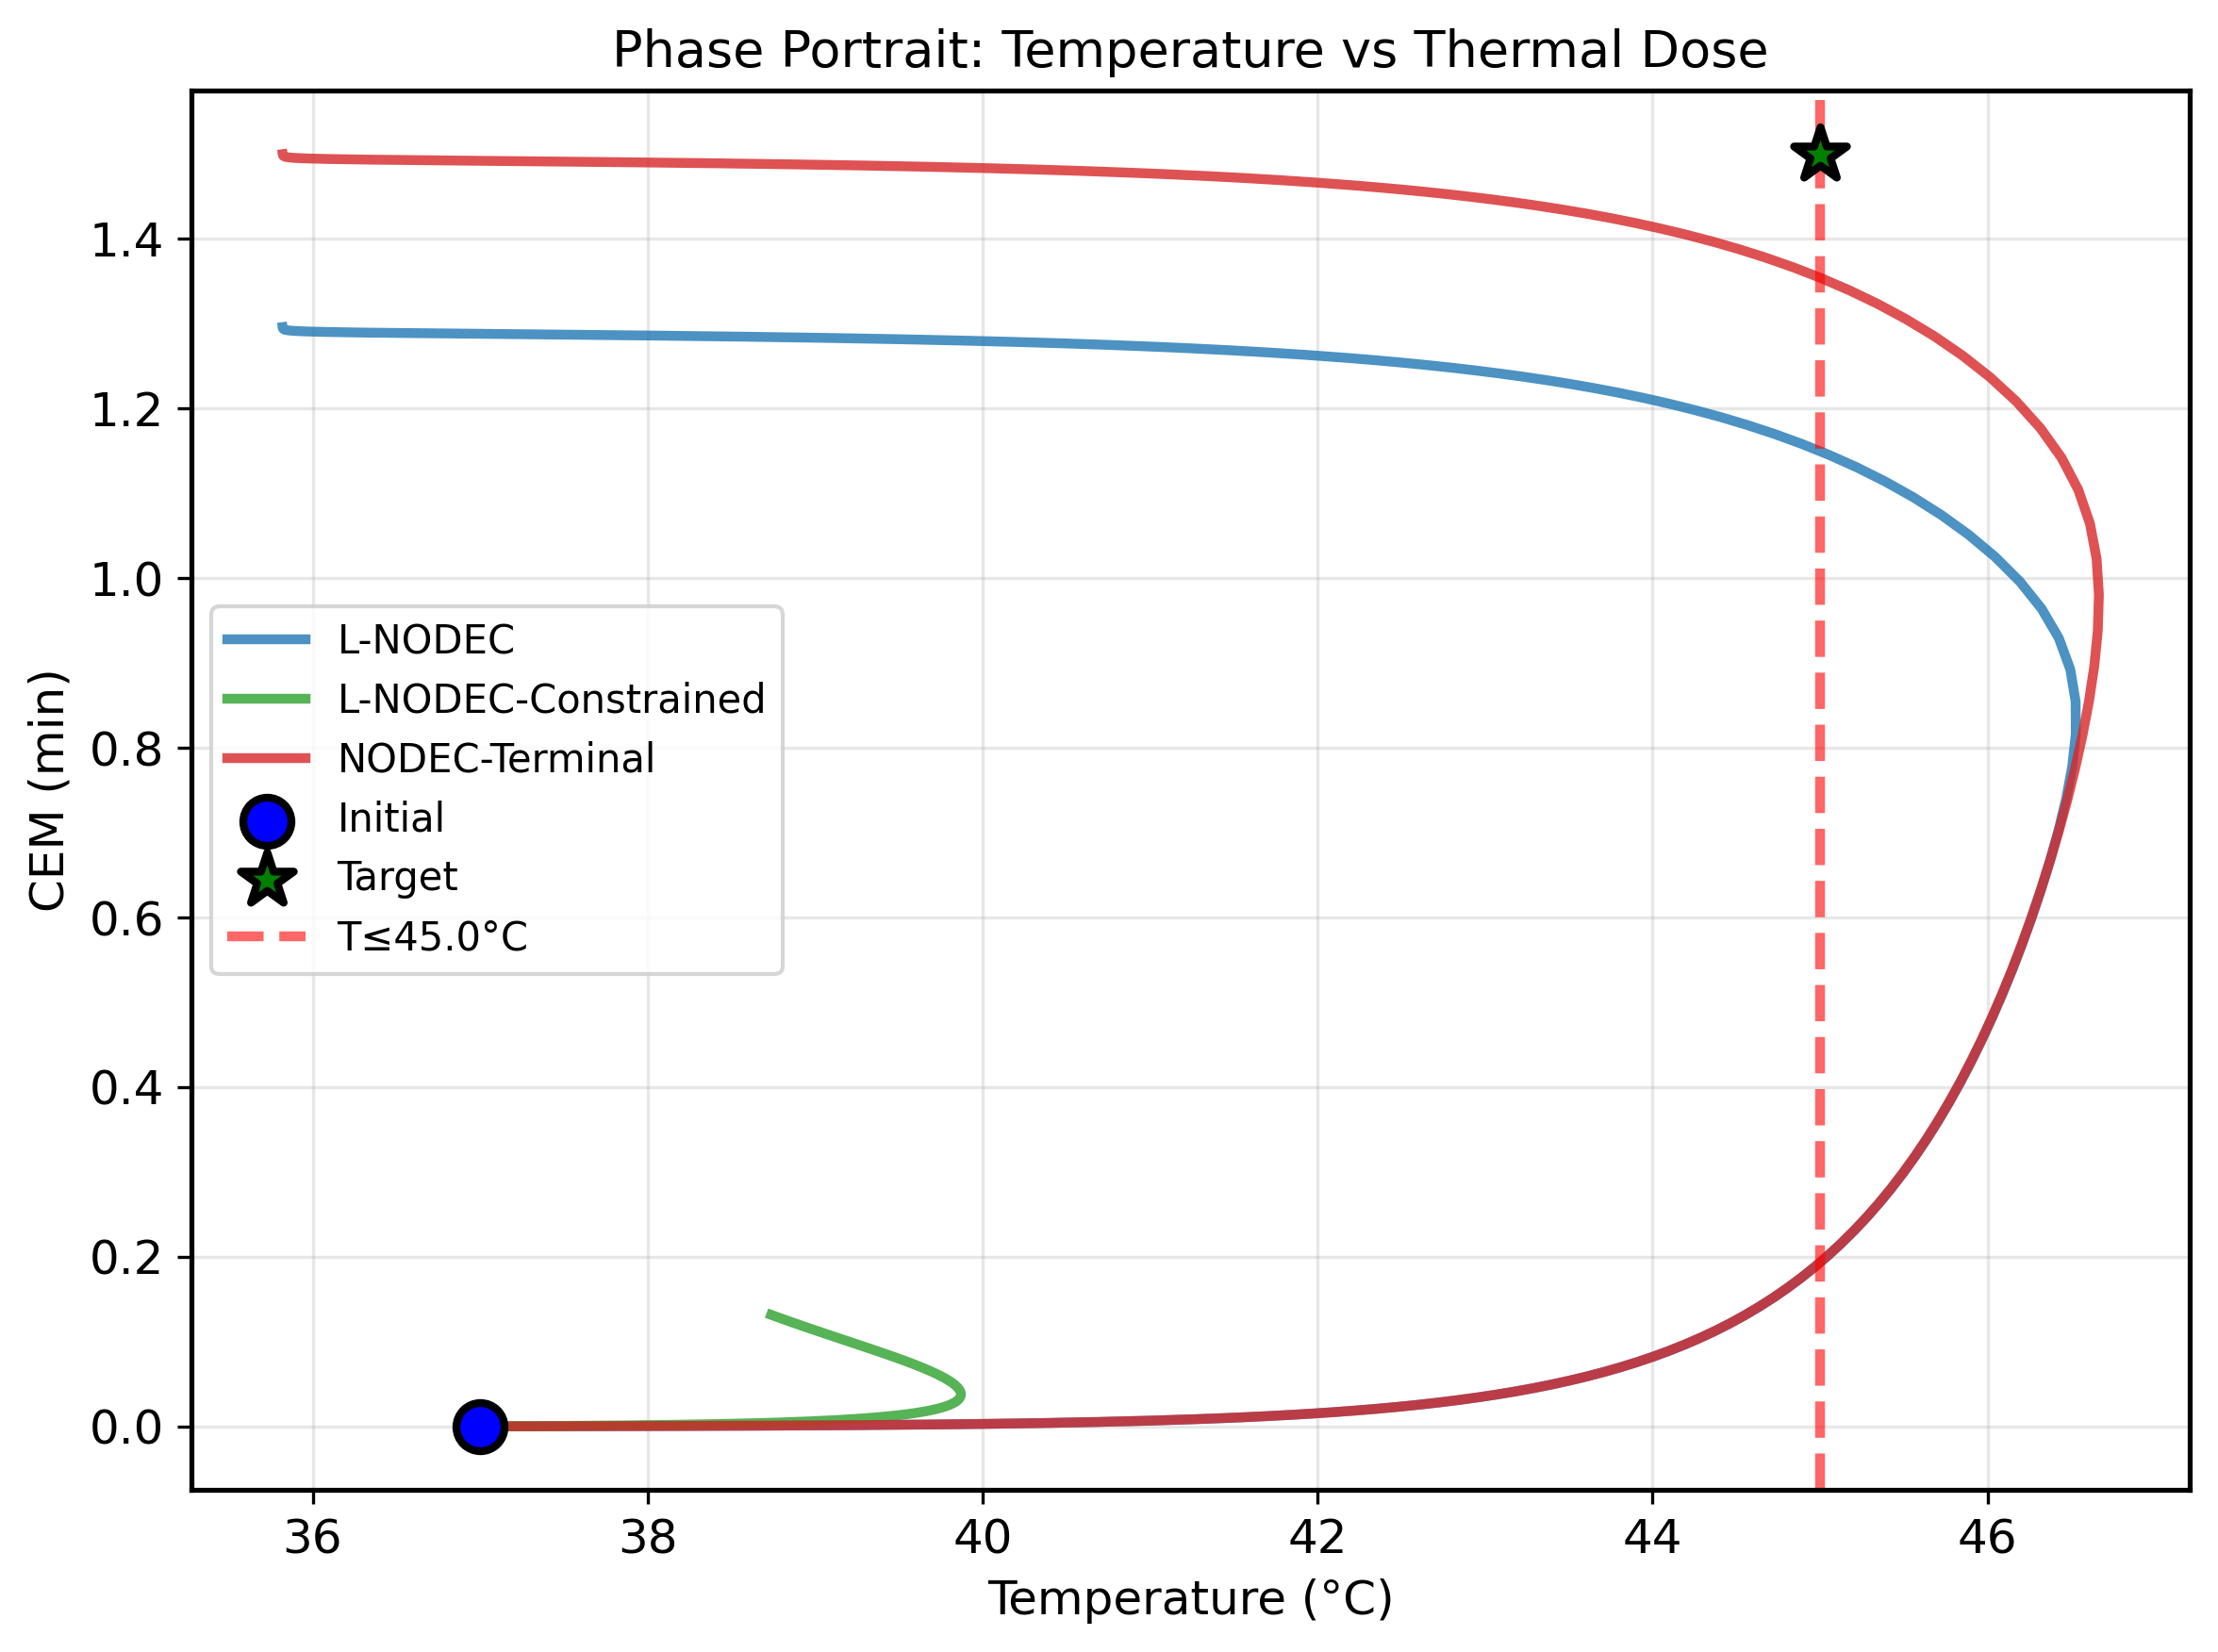

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot trajectories for all methods
for method_name, traj in trajectories_all.items():
    ax.plot(traj[:, 0], traj[:, 1], color=colors_methods[method_name],
            linewidth=2.5, label=method_name, alpha=0.8)

# Mark initial and target states
ax.scatter(x0[0].item(), x0[1].item(), color='blue', s=150, marker='o', 
          edgecolors='black', linewidth=2, zorder=5, label='Initial')
ax.scatter(z_target[0].item(), z_target[1].item(), color='green', s=200, marker='*',
          edgecolors='black', linewidth=2, zorder=5, label='Target')

# Add constraint line
ax.axvline(T_max_constrained, color='red', linestyle='--', linewidth=2.5, alpha=0.6, label=f'T≤{T_max_constrained}°C')

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('CEM (min)', fontsize=12)
ax.set_title('Phase Portrait: Temperature vs Thermal Dose', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Training Loss Comparison

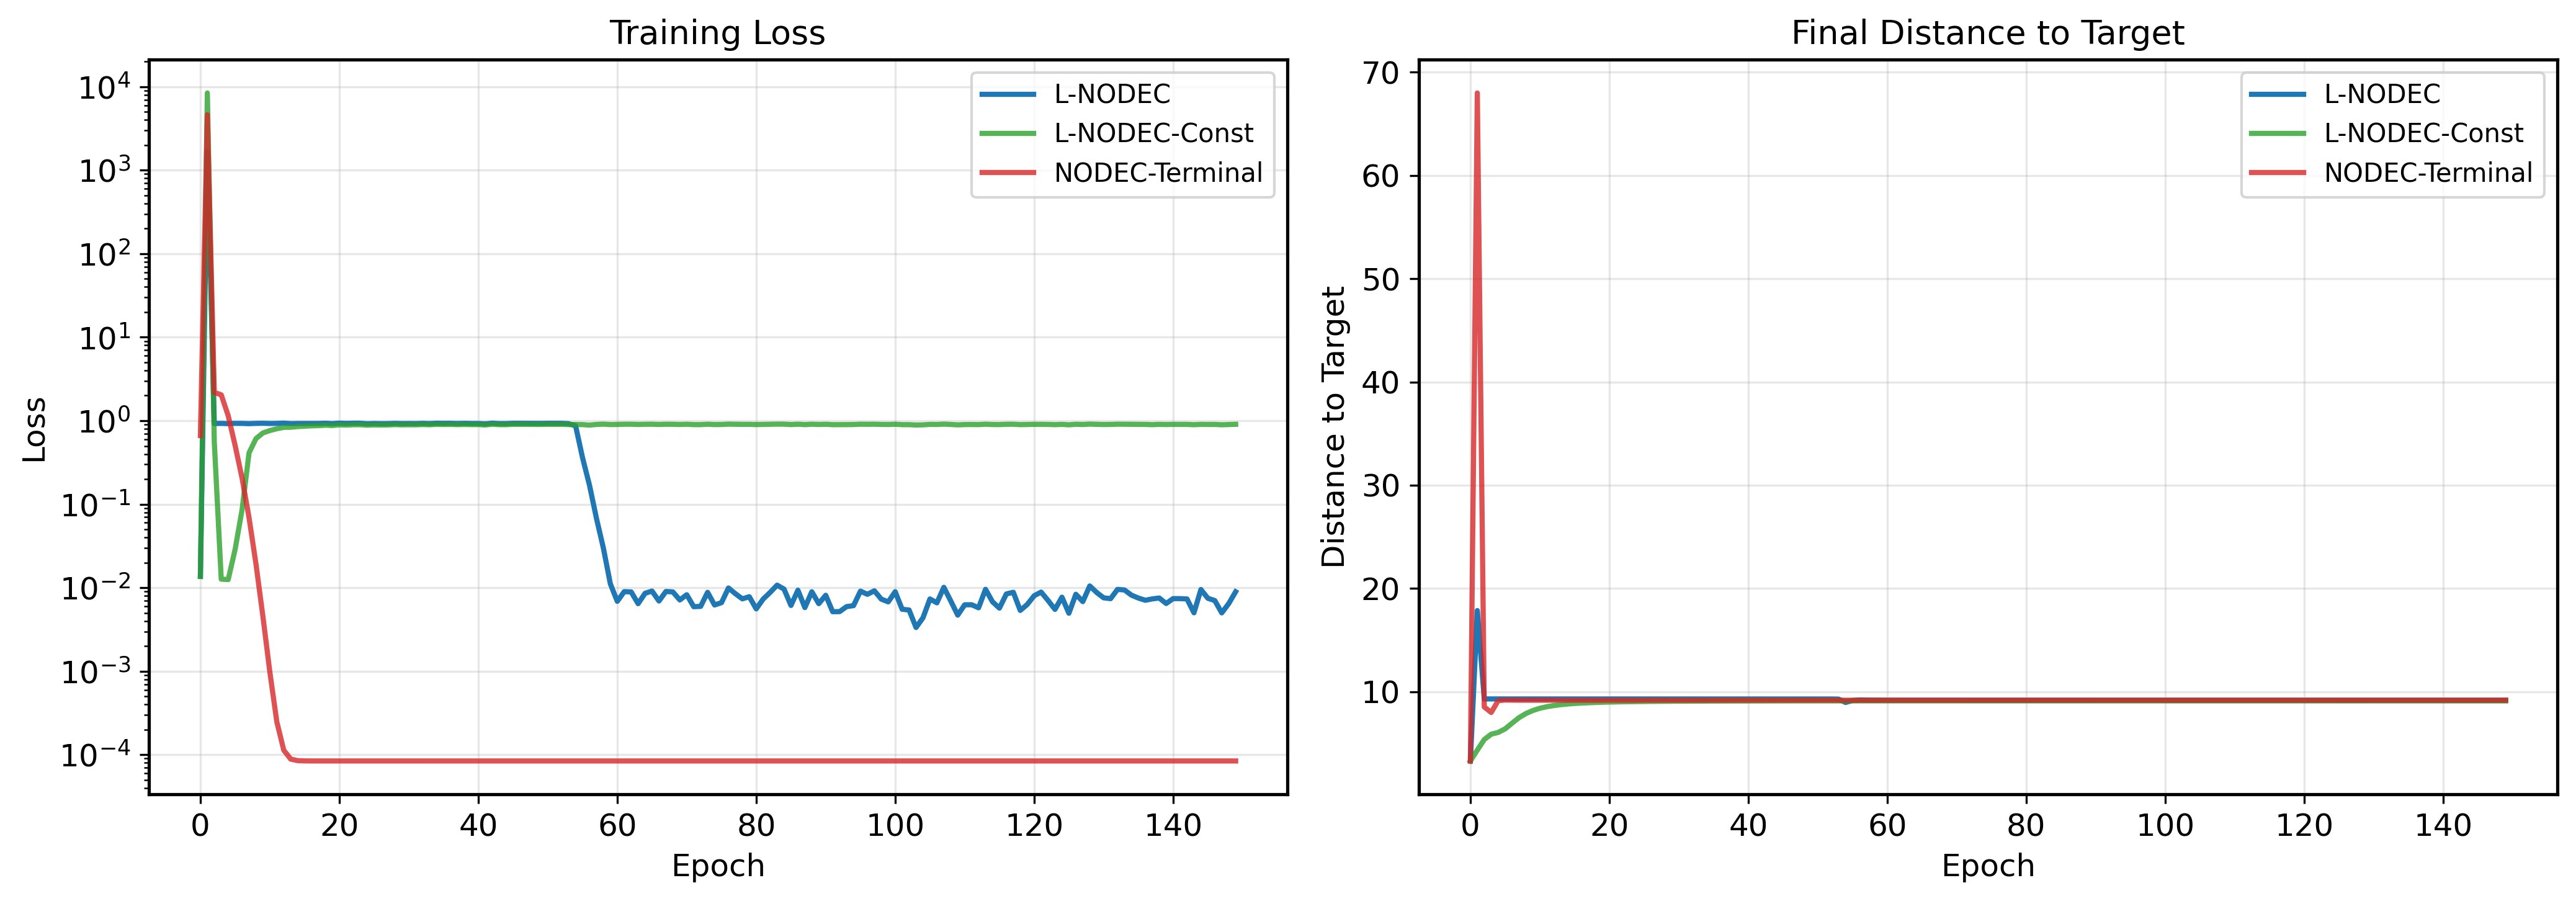

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss over epochs
axes[0].plot(history['loss'], linewidth=2, color=COLORS['primary'], label='L-NODEC')
axes[0].plot(history_constrained['loss'], linewidth=2, color=COLORS['success'], label='L-NODEC-Const', alpha=0.8)
axes[0].plot(history_terminal['loss'], linewidth=2, color=COLORS['danger'], label='NODEC-Terminal', alpha=0.8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13)
axes[0].set_yscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Final distance over epochs
axes[1].plot(history['final_distance'], linewidth=2, color=COLORS['primary'], label='L-NODEC')
axes[1].plot(history_constrained['final_distance'], linewidth=2, color=COLORS['success'], label='L-NODEC-Const', alpha=0.8)
axes[1].plot(history_terminal['final_distance'], linewidth=2, color=COLORS['danger'], label='NODEC-Terminal', alpha=0.8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Distance to Target', fontsize=12)
axes[1].set_title('Final Distance to Target', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Robustness: Initial Temperature Perturbations (35–39°C)

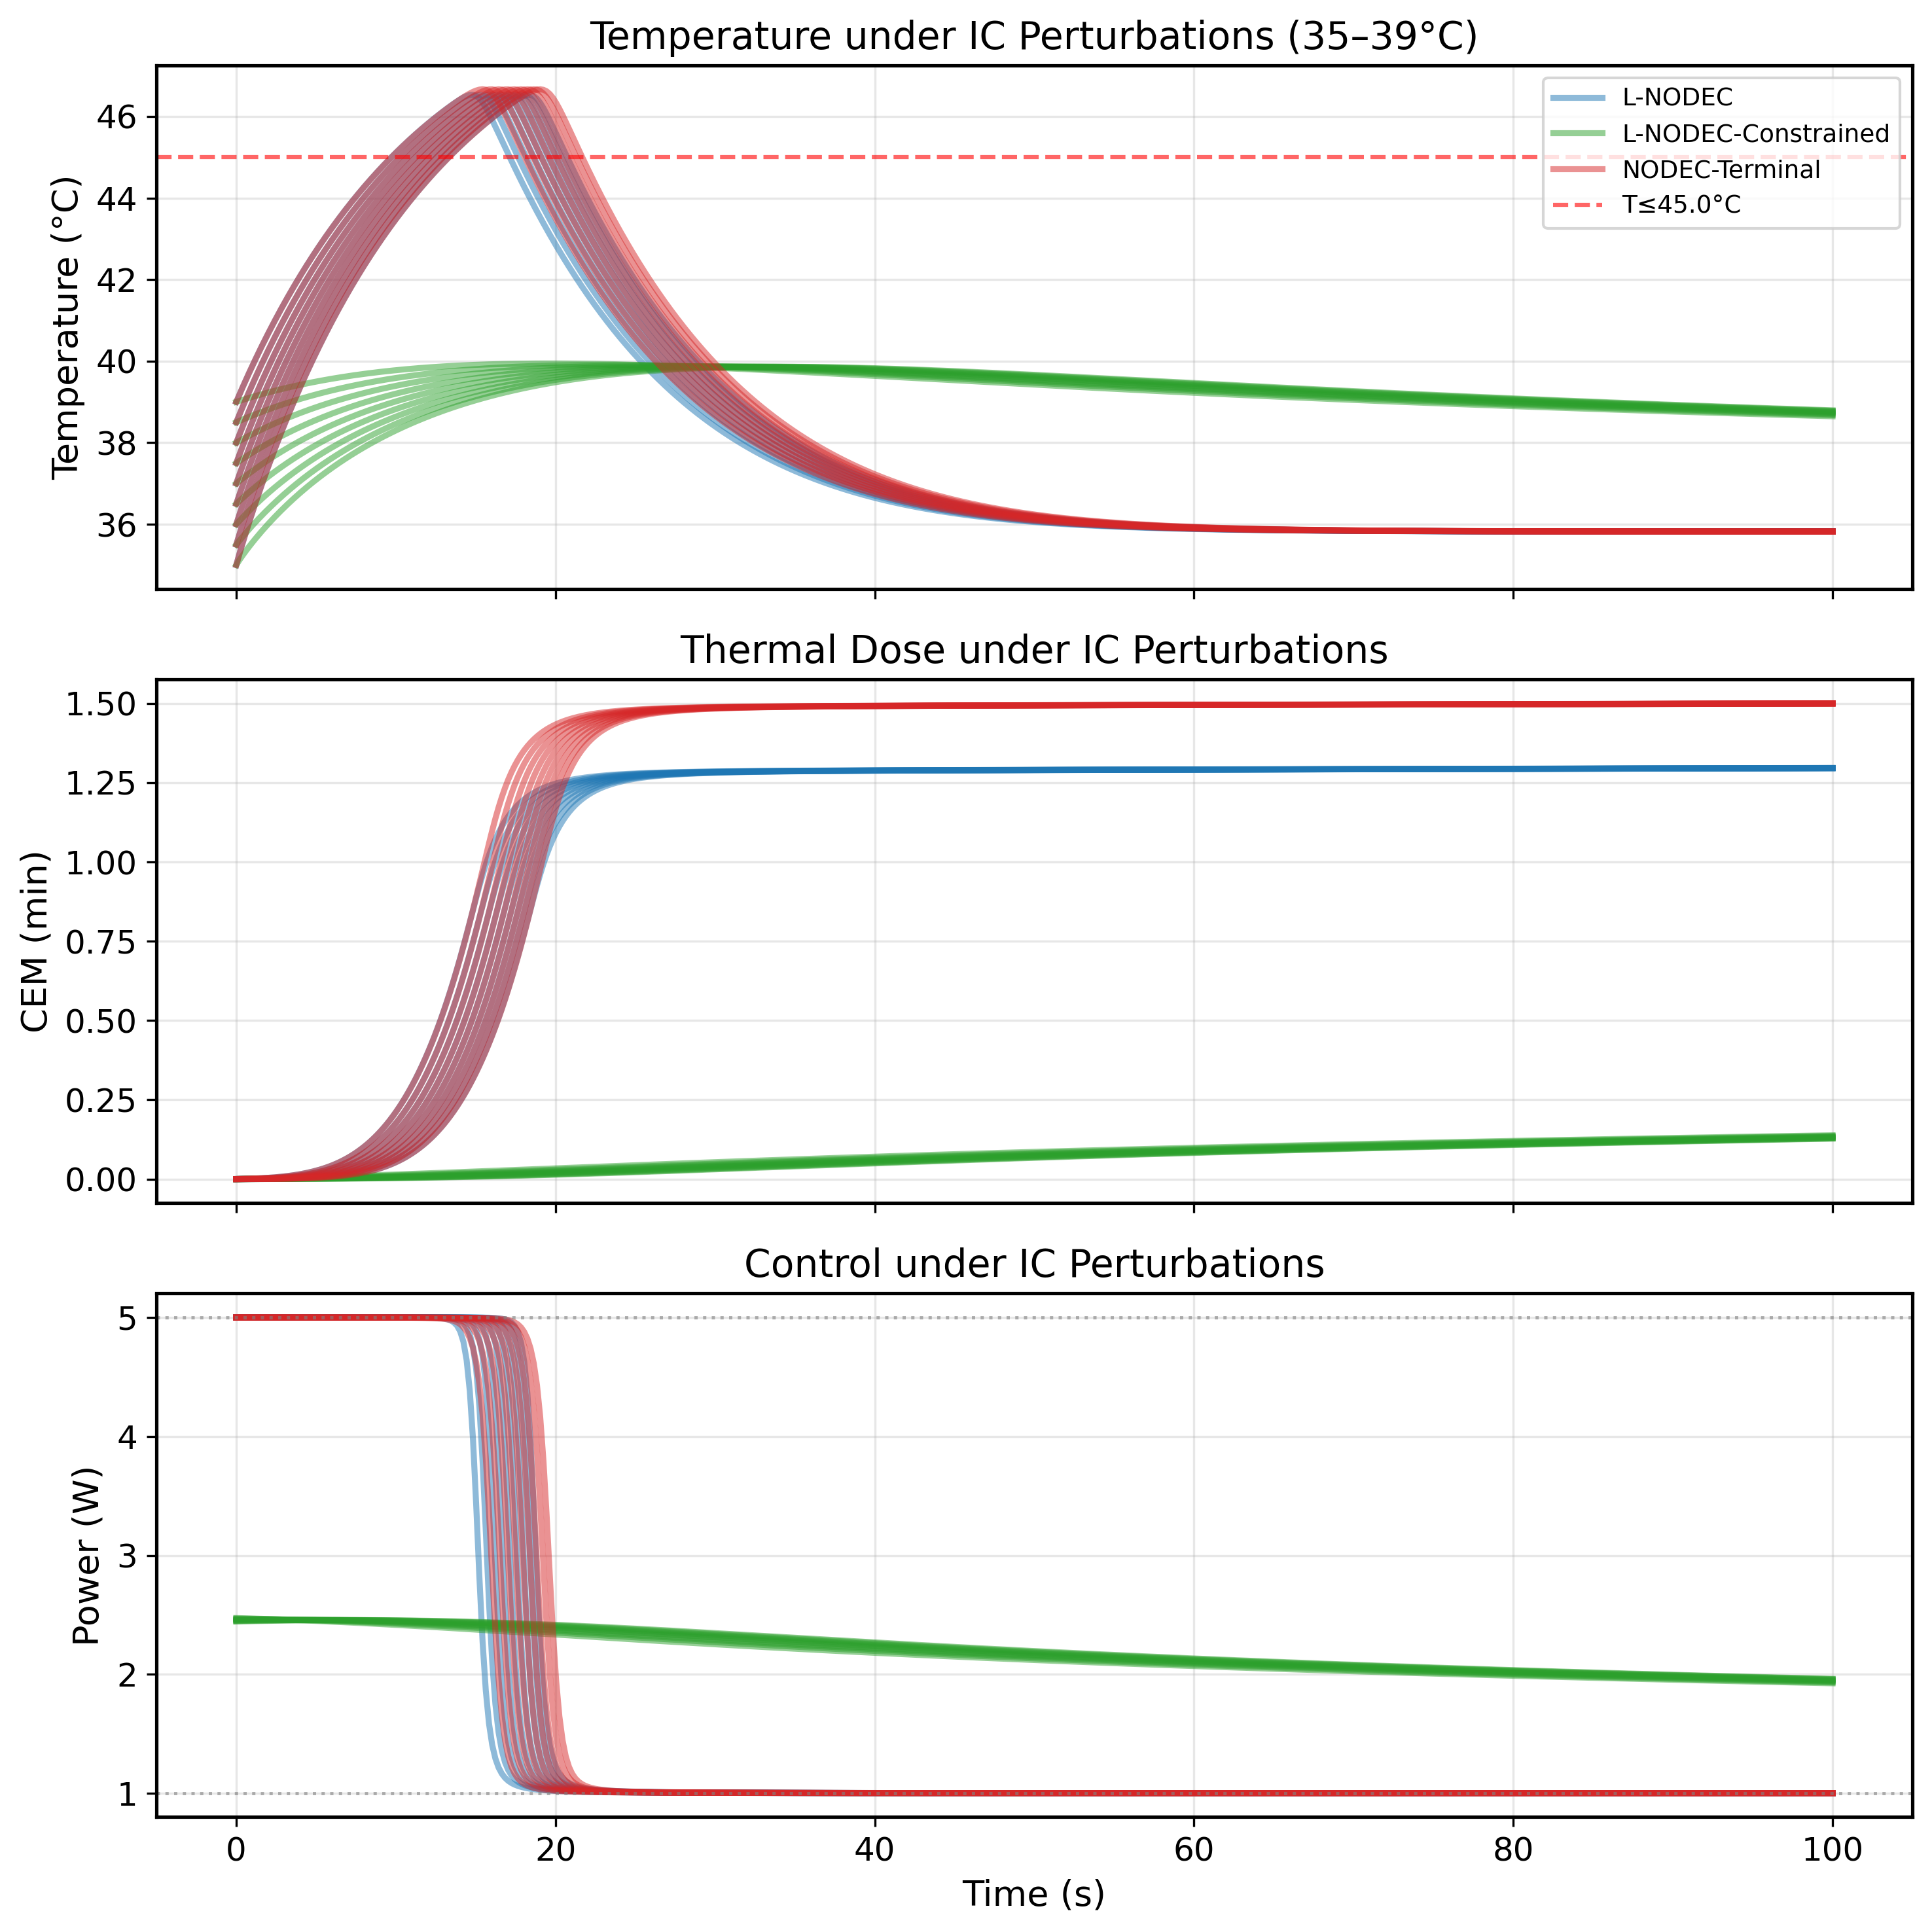

In [11]:
# Evaluate policies under varying initial temperatures
temp_range = np.linspace(35.0, 39.0, 9)

methods = {
    'L-NODEC': trainer,
    'L-NODEC-Constrained': trainer_constrained,
    'NODEC-Terminal': trainer_terminal,
}

trajectories_by_method = {k: [] for k in methods}
controls_by_method = {k: [] for k in methods}

for T0 in temp_range:
    x0_test = torch.tensor([T0, 0.0], dtype=dtype, device=device)
    for name, tr in methods.items():
        # Handle different evaluate signatures
        if name == 'NODEC-Terminal':
            # NODECTrainer.evaluate() doesn't accept compute_stability_metrics
            res = tr.evaluate(x0_test, z_target, time_grid)
        else:
            # LNODECTrainer.evaluate() accepts compute_stability_metrics
            res = tr.evaluate(x0_test, z_target, time_grid, compute_stability_metrics=False)
        trajectories_by_method[name].append(res['trajectory'].cpu().numpy())
        controls_by_method[name].append(res['controls'].cpu().numpy())

time_grid_np = time_grid.cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Temperature
for method_name in methods.keys():
    color = colors_methods[method_name]
    for i, traj in enumerate(trajectories_by_method[method_name]):
        label = method_name if i == 0 else None
        axes[0].plot(time_grid_np, traj[:, 0], color=color, alpha=0.5, label=label)
axes[0].axhline(T_max_constrained, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label=f'T≤{T_max_constrained}°C')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Temperature under IC Perturbations (35–39°C)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# CEM
for method_name in methods.keys():
    color = colors_methods[method_name]
    for i, traj in enumerate(trajectories_by_method[method_name]):
        label = method_name if i == 0 else None
        axes[1].plot(time_grid_np, traj[:, 1], color=color, alpha=0.5, label=label)
axes[1].set_ylabel('CEM (min)')
axes[1].set_title('Thermal Dose under IC Perturbations')
axes[1].grid(True, alpha=0.3)

# Control
for method_name in methods.keys():
    color = colors_methods[method_name]
    for i, ctrl in enumerate(controls_by_method[method_name]):
        ctrl_np = ctrl.squeeze(-1) if ctrl.ndim > 2 else ctrl
        label = method_name if i == 0 else None
        axes[2].plot(time_grid_np, ctrl_np, color=color, alpha=0.5, label=label)
axes[2].axhline(u_min, color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
axes[2].axhline(u_max, color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Power (W)')
axes[2].set_title('Control under IC Perturbations')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()